<div style="text-align: center;">
    <h1 style="
        background: linear-gradient(135deg, #87003aff, #3d001aff);
        color: white; 
        padding: 15px 30px; 
        border-radius: 500px; 
        font-family: 'Segoe UI', Arial, sans-serif; 
        box-shadow: 0 4px 15px rgba(0,0,0,0.3);
        display: inline-block;
    ">
       Diabetes Prediction using SVM && Random Forest Classifier
    </h1>
</div>



<h4 style="color:#d2005bff">
1. Importing libraries for 
<strong>data handling</strong> (<span style="color:#007acc">pandas</span>, <span style="color:#007acc">numpy</span>), 
<strong>evaluation metrics</strong> (<span style="color:#007acc">accuracy</span>, <span style="color:#007acc">confusion matrix</span>, <span style="color:#007acc">classification report</span>, <span style="color:#007acc">precision-recall</span>, <span style="color:#007acc">ROC</span>, <span style="color:#007acc">AUC</span>), 
<strong>model selection</strong> (<span style="color:#007acc">train_test_split</span>, <span style="color:#007acc">GridSearchCV</span>), 
<strong>preprocessing</strong> (<span style="color:#007acc">StandardScaler</span>, <span style="color:#007acc">Pipeline</span>), 
<strong>machine learning models</strong> (<span style="color:#007acc">RandomForest</span>, <span style="color:#007acc">SVM</span>), 
and <strong>visualization</strong> (<span style="color:#007acc">matplotlib</span>, <span style="color:#007acc">seaborn</span>)
</h4>


In [105]:
import pandas as pd
pd.set_option("display.max_columns",20)
import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_recall_curve, average_precision_score,roc_curve,auc
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns

<h4 style="color:#d2005bff">
2. Loading dataset (<span style="color:#007acc">diabetes.csv</span>) using <span style="color:#007acc">pandas.read_csv</span> from local directory path
</h4>


In [106]:
diabetes=pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\GTC-ML-internship\Week 2 Project\Data\diabetes.csv")

In [107]:
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<h4 style="color:#d2005bff">
3. Generating statistical summary of dataset using <span style="color:#007acc">diabetes.describe().T</span> (transpose for readability)
</h4>


In [108]:
diabetes.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


<h4 style="color:#d2005bff">
4. Exploring dataset structure using <span style="color:#007acc">diabetes.info()</span> to view column types & non-null counts, 
and <span style="color:#007acc">diabetes.shape</span> to check dataset dimensions (rows, columns)
</h4>


In [109]:
print(diabetes.info())
print('---------------------------------------------------')
print(diabetes.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
---------------------------------------------------
(768, 9)


<h4 style="color:#d2005bff">
5. Checking percentage of zero values in critical features: 
<span style="color:#007acc">BloodPressure</span>, 
<span style="color:#007acc">Insulin</span>, 
<span style="color:#007acc">Glucose</span> 
(using boolean filtering and normalization by dataset size)
</h4>


In [110]:
total_zerospar1 = ((diabetes['BloodPressure'] == 0).sum().sum())/np.prod(diabetes.shape)
print(f"Count Number Zero in  BloodPressure {total_zerospar1*100:.2f} %")
total_zerospar2 = ((diabetes['Insulin'] == 0).sum().sum())/np.prod(diabetes.shape)
print(f"Count Number Zero in  Insulin {total_zerospar2*100:.2f} %")
total_zerospar3 = ((diabetes['Glucose'] == 0).sum().sum())/np.prod(diabetes.shape)
print(f"Count Number Zero in  Glucose {total_zerospar3*100:.2f} %")

Count Number Zero in  BloodPressure 0.51 %
Count Number Zero in  Insulin 5.41 %
Count Number Zero in  Glucose 0.07 %


<h4 style="color:#d2005bff">
6. Exploring target variable <span style="color:#007acc">Outcome</span> distribution: 
using <span style="color:#007acc">value_counts()</span> to count diabetic vs non-diabetic cases, 
and visualizing the results with a <span style="color:#007acc">bar plot</span> (blue = Not diabetic, orange = Diabetic)
</h4>


Outcome
0    500
1    268
Name: count, dtype: int64
---------------------------------------------------


[Text(0.5, 0, 'Outcome'), Text(0, 0.5, 'Count')]

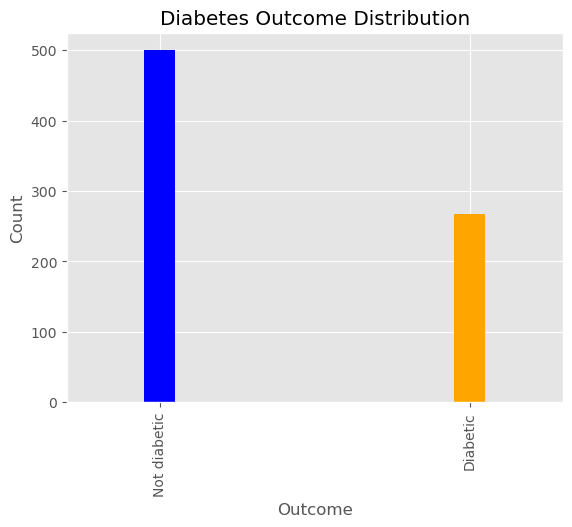

In [111]:
print(diabetes['Outcome'].value_counts())
print('---------------------------------------------------')
diabetes['Outcome'].value_counts().rename({0:"Not diabetic",1:"Diabetic"}).plot(kind='bar', color=['blue','orange'], width=0.1, title="Diabetes Outcome Distribution").set(xlabel="Outcome", ylabel="Count")

<h4 style="color:#d2005bff">
7. Grouping dataset by <span style="color:#007acc">Outcome</span> and calculating 
feature-wise <span style="color:#007acc">mean values</span> to compare diabetic vs non-diabetic patients
</h4>


In [112]:
diabetes.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


<h4 style="color:#d2005bff">
8. Visualizing <span style="color:#007acc">Age distribution</span> of patients using 
<span style="color:#007acc">seaborn.histplot</span> with 80 bins and dark red color
</h4>


<Axes: xlabel='Age', ylabel='Count'>

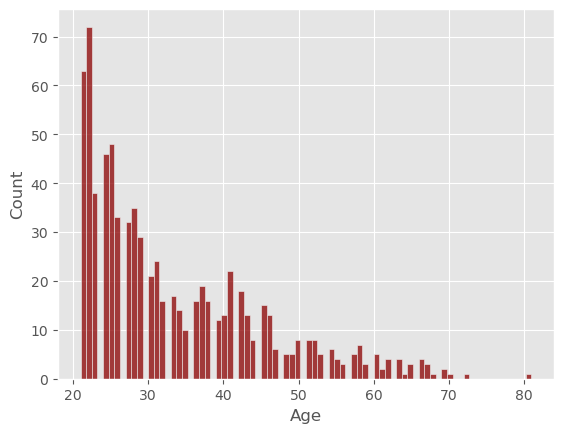

In [113]:
sns.histplot(diabetes['Age'],color='darkred',bins=80)

<h4 style="color:#d2005bff">
9. Comparing <span style="color:#007acc">BMI distribution</span> across diabetic vs non-diabetic patients 
using <span style="color:#007acc">seaborn.boxplot</span> with <span style="color:#007acc">Outcome</span> as categorical variable
</h4>

<Axes: xlabel='Outcome', ylabel='BMI'>

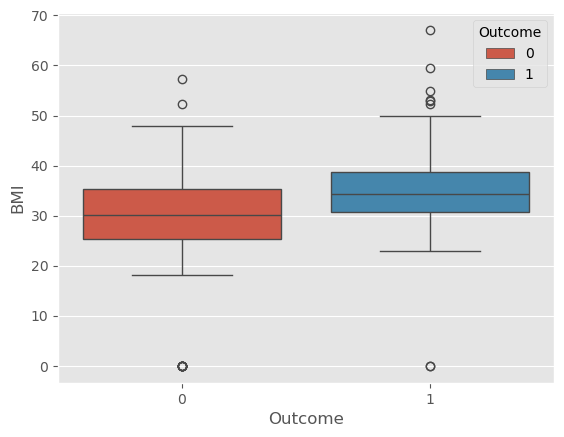

In [114]:
sns.boxplot(x=diabetes['Outcome'],y=diabetes['BMI'],hue=diabetes['Outcome'])

<h4 style="color:#d2005bff">
10. Comparing <span style="color:#007acc">Glucose distribution</span> across diabetic vs non-diabetic patients 
using <span style="color:#007acc">seaborn.boxplot</span> with <span style="color:#007acc">Outcome</span> as categorical variable
</h4>

<Axes: xlabel='Outcome', ylabel='Glucose'>

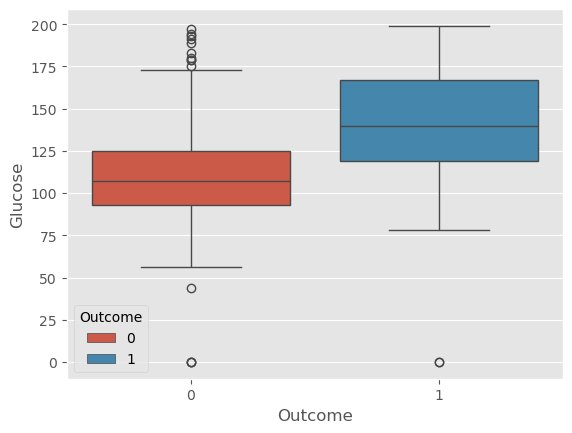

In [115]:
sns.boxplot(x=diabetes['Outcome'],y=diabetes['Glucose'],hue=diabetes['Outcome'])

<h4 style="color:#d2005bff">
11. Visualizing <span style="color:#007acc">Outcome distribution</span> as a 
<span style="color:#007acc">pie chart</span> showing percentage of diabetic vs non-diabetic patients
</h4>

([<matplotlib.patches.Wedge at 0x236a7752850>,
 [Text(-0.5025944173008549, 0.9784676038060812, 'Not diabetic'),
  Text(0.502594502841211, -0.9784675598678764, 'Diabetic')],
 [Text(-0.2741424094368299, 0.5337096020760442, '65.1%'),
  Text(0.27414245609520593, -0.5337095781097507, '34.9%')])

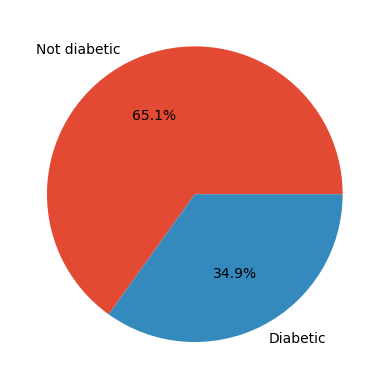

In [116]:
plt.pie(diabetes['Outcome'].value_counts(),labels=diabetes['Outcome'].value_counts().rename({0:"Not diabetic",1:"Diabetic"}).index,autopct="%1.1f%%")

<h4 style="color:#d2005bff">
12. Visualizing feature correlations using <span style="color:#007acc">seaborn.heatmap</span> 
with <span style="color:#007acc">annotated correlation values</span>, 
<span style="color:#007acc">coolwarm colormap</span>, and figure size (15x5)
</h4>

<Axes: >

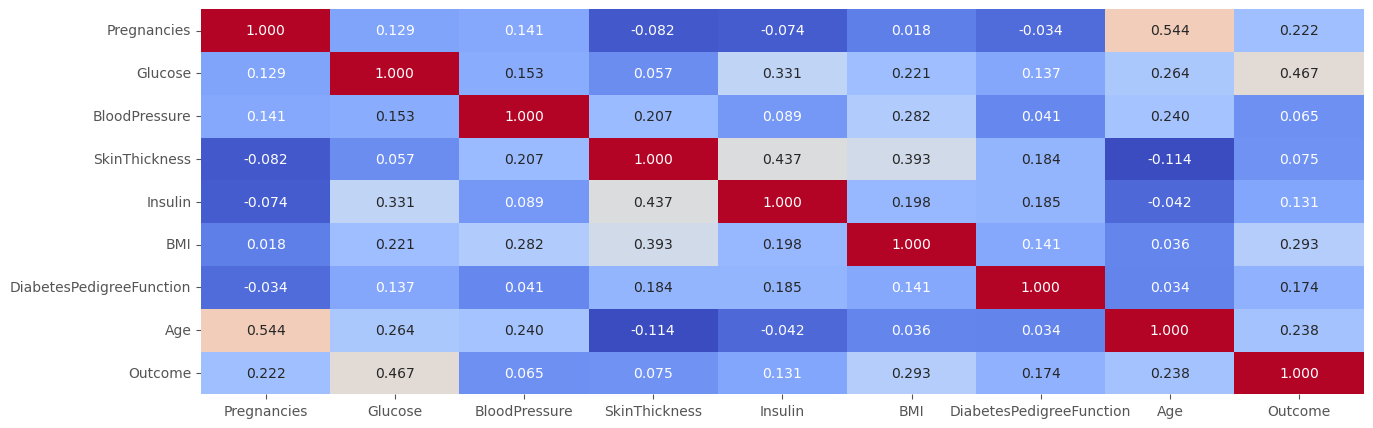

In [117]:
plt.figure(figsize=(15,5))
sns.heatmap(diabetes.corr(numeric_only=True),annot=True,cbar=False,fmt=".3f",cmap="coolwarm")

<h4 style="color:#d2005bff">
13. Exploring pairwise relationships between features using 
<span style="color:#007acc">seaborn.pairplot</span> with <span style="color:#007acc">Outcome</span> as hue 
(dark red = Diabetic, dark blue = Not diabetic)
</h4>

<Figure size 1500x500 with 0 Axes>

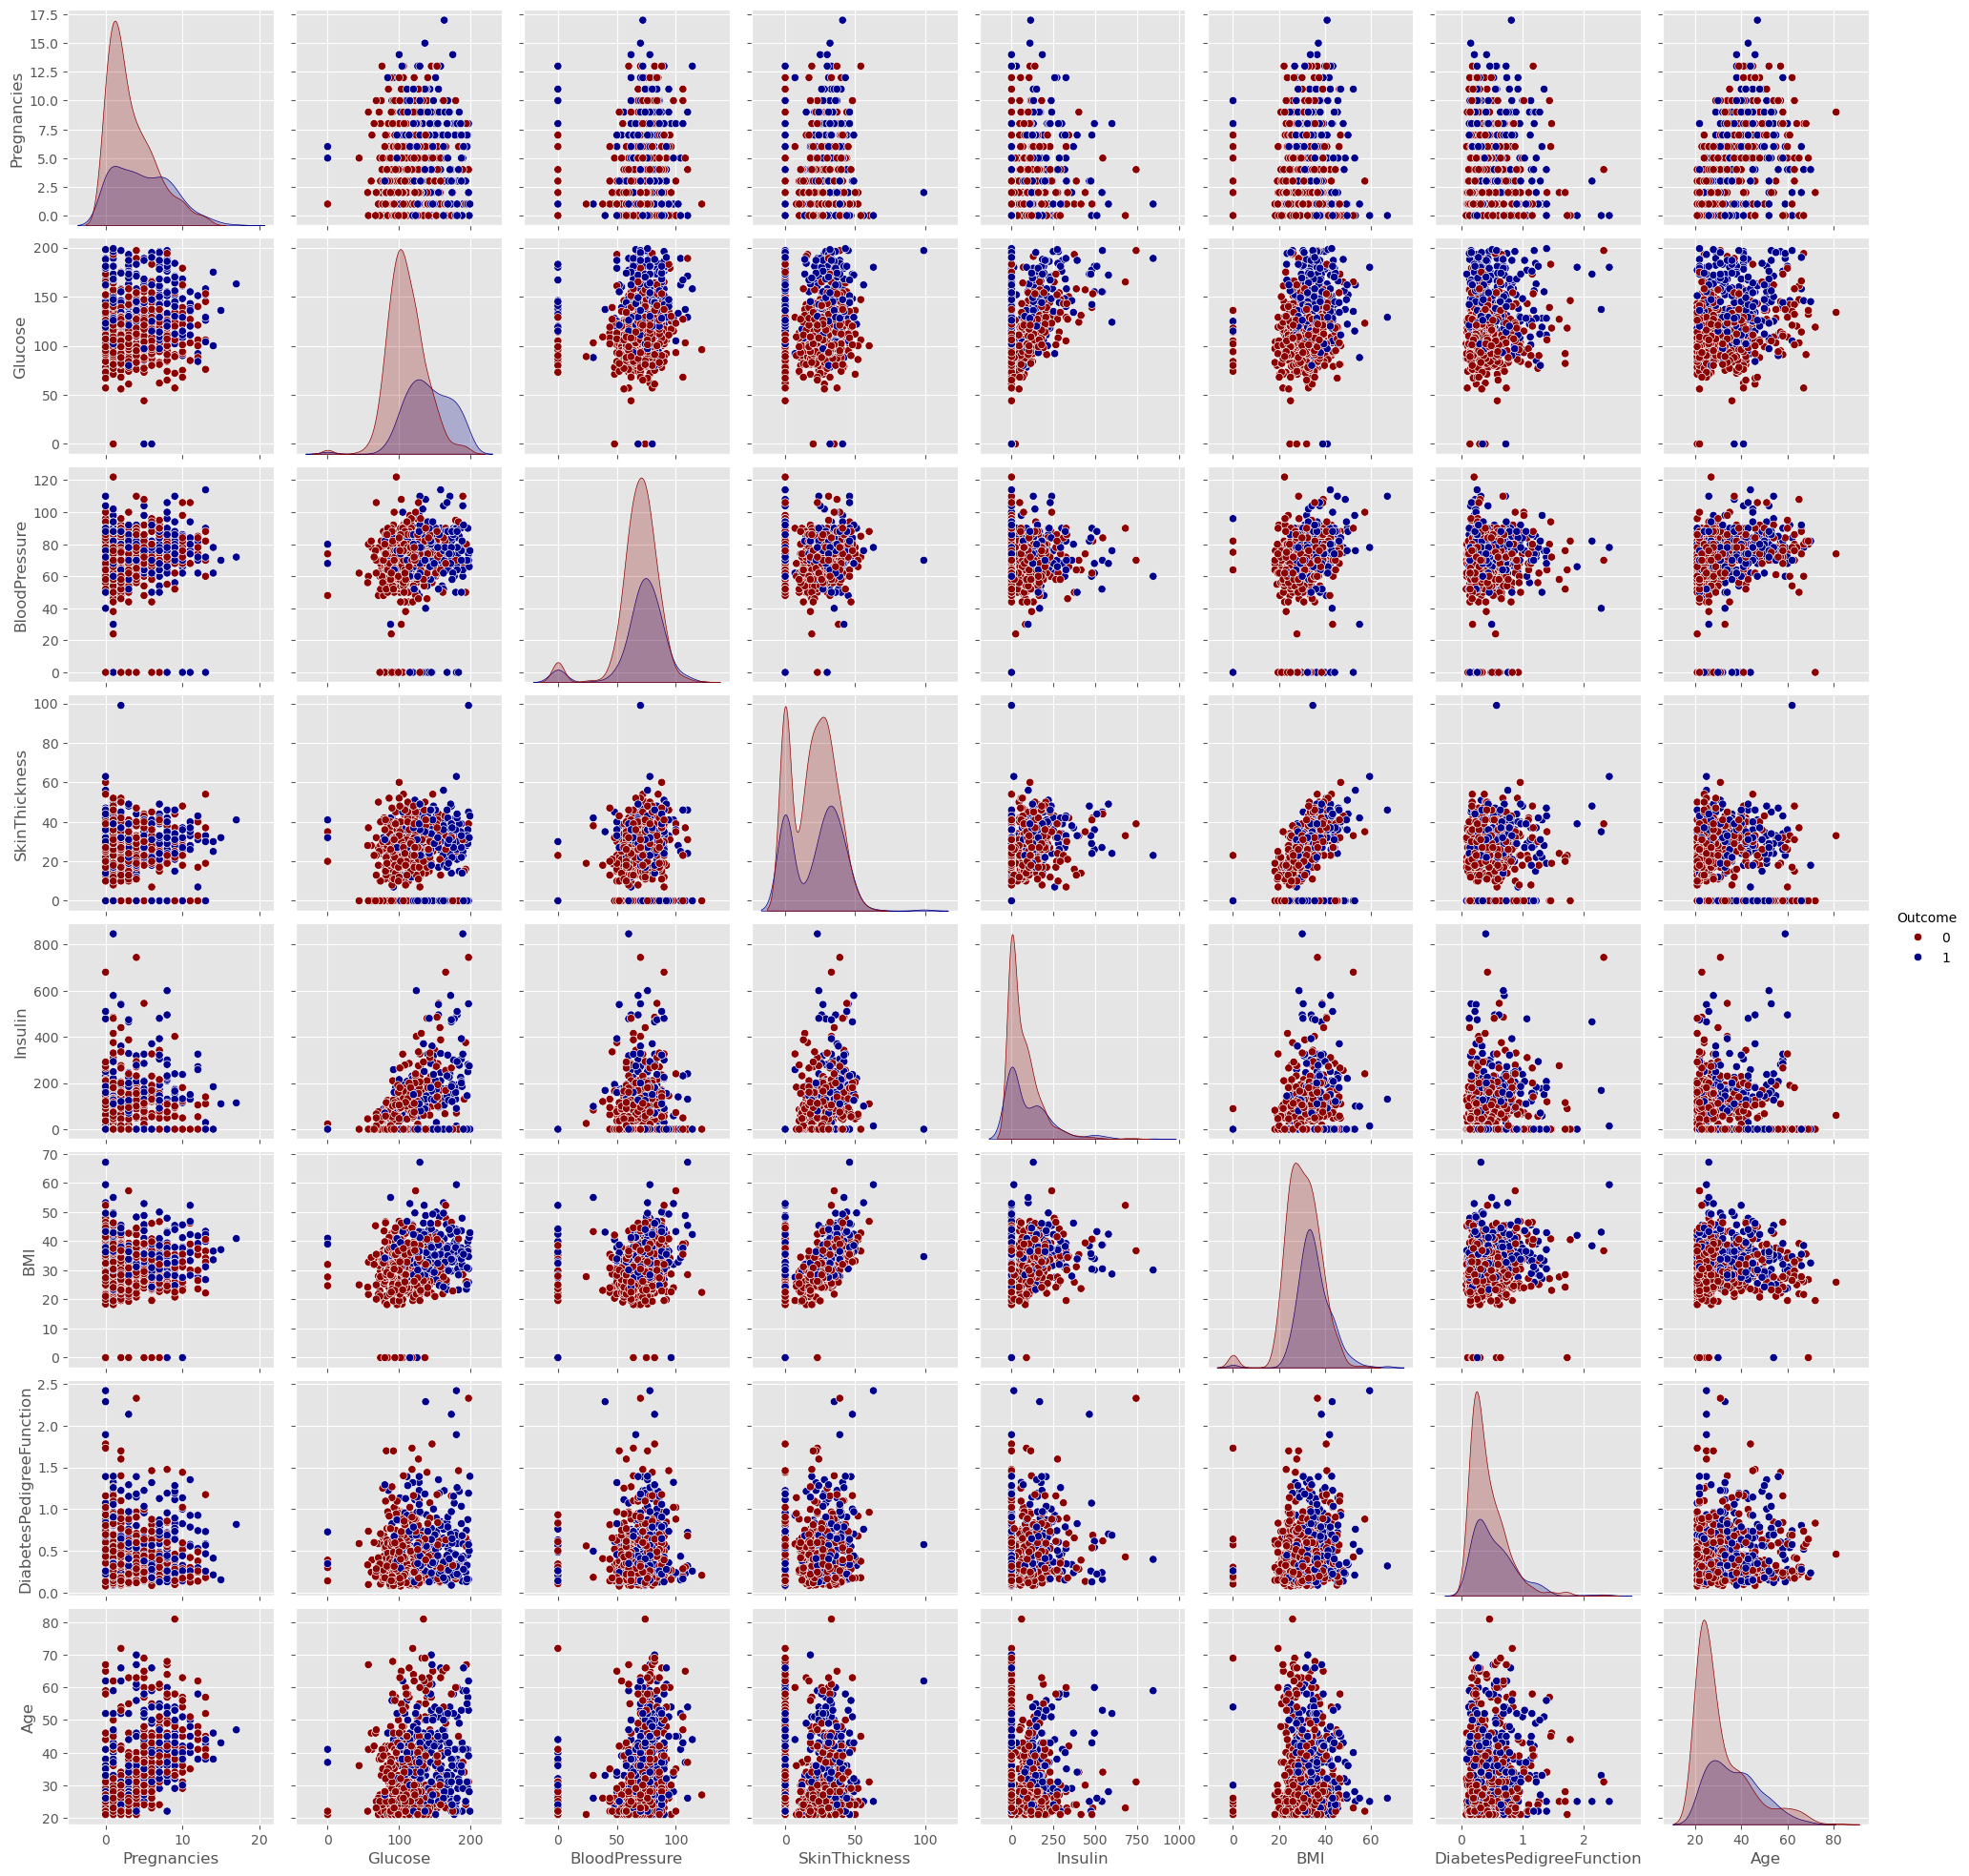

In [118]:
plt.figure(figsize=(15,5))
sns.pairplot(data=diabetes,hue="Outcome",palette=['darkred',"darkblue"])
plt.show()

<h4 style="color:#d2005bff">
14. Visualizing bivariate relationships using <span style="color:#007acc">scatter plots</span>: 
(<span style="color:#007acc">Age vs BMI</span>) and (<span style="color:#007acc">Age vs Insulin</span>) 
with <span style="color:#007acc">Outcome</span> as hue (Diabetic vs Not diabetic)
</h4>

<Axes: xlabel='Age', ylabel='Insulin'>

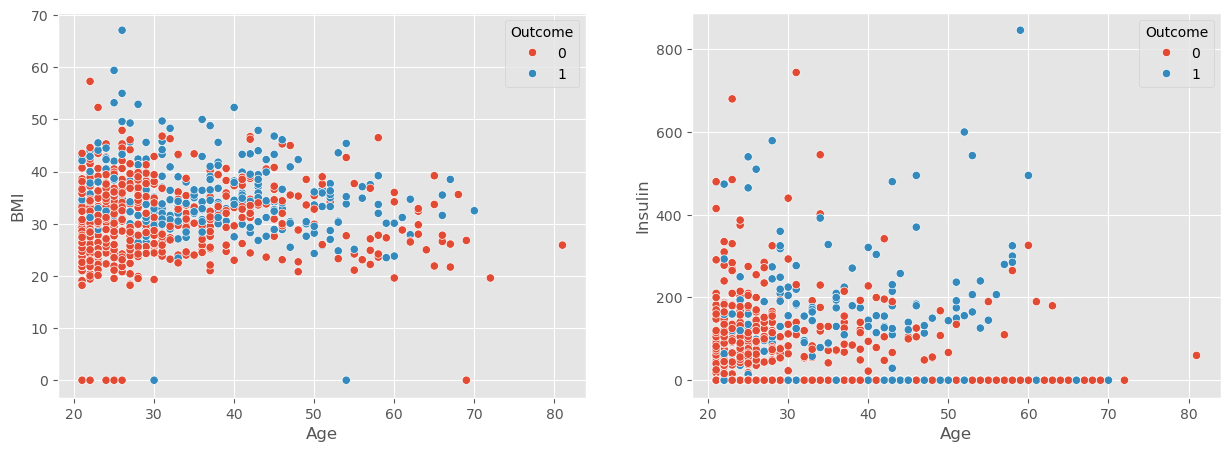

In [119]:
fig,axes=plt.subplots(1,2,figsize=(15,5))
sns.scatterplot(x=diabetes['Age'],y=diabetes['BMI'],hue=diabetes['Outcome'],ax=axes[0])
sns.scatterplot(x=diabetes['Age'],y=diabetes['Insulin'],hue=diabetes['Outcome'],ax=axes[1])


<h4 style="color:#d2005bff">
15. Splitting dataset into <span style="color:#007acc">features (X)</span> and 
<span style="color:#007acc">target (y = Outcome)</span> for model training
</h4>


In [120]:
x=diabetes.drop(columns=['Outcome'],axis=1)
y=diabetes['Outcome']

<h4 style="color:#d2005bff">
16. Splitting dataset into <span style="color:#007acc">training (80%)</span> and 
<span style="color:#007acc">testing (20%)</span> sets using 
<span style="color:#007acc">train_test_split</span> with <span style="color:#007acc">stratification on Outcome</span> 
and random_state = 2 for reproducibility
</h4>


In [121]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2,stratify=y)

<h4 style="color:#d2005bff">
17. Building a <span style="color:#007acc">Pipeline</span> with 
<span style="color:#007acc">StandardScaler</span> and 
<span style="color:#007acc">SVM (RBF kernel, probability=True, class_weight="balanced")</span>, 
and tuning hyperparameters (<span style="color:#007acc">C</span>, <span style="color:#007acc">gamma</span>) 
using <span style="color:#007acc">GridSearchCV</span> (5-fold CV, scoring = F1, parallel jobs enabled)
</h4>


In [122]:
pi1= Pipeline([
    ("scaler", StandardScaler()),
    ("para", svm.SVC(kernel='rbf', probability=True, class_weight="balanced"))
])
paramiter1 = {
    "para__C": [0.1, 1, 10, 100],
    "para__gamma": ["scale", 0.01, 0.1, 1]
}
clasdifer1 = GridSearchCV(pi1, paramiter1, cv=5, scoring="f1", n_jobs=-1)
clasdifer1.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('para',
                                        SVC(class_weight='balanced',
                                            probability=True))]),
             n_jobs=-1,
             param_grid={'para__C': [0.1, 1, 10, 100],
                         'para__gamma': ['scale', 0.01, 0.1, 1]},
             scoring='f1')

<h4 style="color:#d2005bff">
18. Building a <span style="color:#007acc">Pipeline</span> with 
<span style="color:#007acc">StandardScaler</span> and 
<span style="color:#007acc">RandomForestClassifier (class_weight="balanced", random_state=42)</span>, 
and tuning hyperparameters (<span style="color:#007acc">n_estimators</span>, 
<span style="color:#007acc">max_depth</span>, 
<span style="color:#007acc">min_samples_split</span>) 
using <span style="color:#007acc">GridSearchCV</span> (5-fold CV, scoring = F1, parallel jobs enabled)
</h4>

In [123]:
pi2= Pipeline([
    ("scaler", StandardScaler()),
    ("para", RandomForestClassifier(class_weight="balanced", random_state=42))
])
paramiter2 = {
    "para__n_estimators": [200, 400],
    "para__max_depth": [None, 5, 10],
    "para__min_samples_split": [2, 5]
}
clasdifer2 = GridSearchCV(pi2, paramiter2, cv=5, scoring="f1", n_jobs=-1)
clasdifer2.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('para',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'para__max_depth': [None, 5, 10],
                         'para__min_samples_split': [2, 5],
                         'para__n_estimators': [200, 400]},
             scoring='f1')

<h4 style="color:#d2005bff">
19. Displaying <span style="color:#007acc">best hyperparameters</span> and 
<span style="color:#007acc">best cross-validation F1 scores</span> 
for <span style="color:#007acc">SVM</span> and <span style="color:#007acc">Random Forest</span> models
</h4>

In [124]:
print("[SVM] Best params:", clasdifer1.best_params_, "| Best CV F1:", clasdifer1.best_score_)
print("[RF ] Best params:", clasdifer2.best_params_, "| Best CV F1:", clasdifer2.best_score_)

[SVM] Best params: {'para__C': 10, 'para__gamma': 0.01} | Best CV F1: 0.6702726889526535
[RF ] Best params: {'para__max_depth': 5, 'para__min_samples_split': 2, 'para__n_estimators': 400} | Best CV F1: 0.682561170865059


<h4 style="color:#d2005bff">
20. Evaluating <span style="color:#007acc">SVM (SVC)</span> model on test data using 
<span style="color:#007acc">accuracy_score</span> and reporting final accuracy percentage
</h4>


In [125]:
x_testpredect=clasdifer1.predict(x_test)
accurcyx_test=accuracy_score(x_testpredect,y_test)
print(f"Accuracy Score of Test data Is : {(accurcyx_test*100):.1f}% By : SVM ->(SVC)")

Accuracy Score of Test data Is : 75.3% By : SVM ->(SVC)


<h4 style="color:#d2005bff">
21. Evaluating <span style="color:#007acc">Random Forest Classifier</span> on test data using 
<span style="color:#007acc">accuracy_score</span> and reporting final accuracy percentage
</h4>

In [126]:
x_testpredect=clasdifer2.predict(x_test)
accurcyx_test=accuracy_score(x_testpredect,y_test)
print(f"Accuracy Score of Test data Is : {(accurcyx_test*100):.1f}% BY : Random Forest Classifier")

Accuracy Score of Test data Is : 74.0% BY : Random Forest Classifier


<h4 style="color:#d2005bff">
22. Generating <span style="color:#007acc">classification report</span> (precision, recall, F1-score, support) 
for <span style="color:#007acc">SVM (SVC)</span> model on test data
</h4>

In [127]:
x_testpredect=clasdifer1.predict(x_test)
classificationReportcsv=classification_report(y_test,x_testpredect)
print(classificationReportcsv)

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       100
           1       0.65      0.65      0.65        54

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



<h4 style="color:#d2005bff">
23. Generating <span style="color:#007acc">classification report</span> (precision, recall, F1-score, support) 
for <span style="color:#007acc">Random Forest Classifier</span> model on test data
</h4>

In [128]:
x_testpredect=clasdifer2.predict(x_test)
classificationReportcsv=classification_report(y_test,x_testpredect)
print(classificationReportcsv)

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       100
           1       0.63      0.63      0.63        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



<h4 style="color:#d2005bff">
24. Defining helper function <span style="color:#007acc">cleck()</span> to interpret model predictions: 
print human-readable result (<span style="color:#007acc">Not diabetic</span> or <span style="color:#007acc">Diabetic</span>)
</h4>


In [144]:
def cleck(datapredict) :
    if datapredict == 0 :
        print("The human is Not diabetic")
    else :
        print("The human is diabetic")

<h4 style="color:#d2005bff">
25. Testing best model (<span style="color:#007acc">SVM best_estimator_</span>) on sample patient inputs 
and interpreting predictions with <span style="color:#007acc">cleck()</span> function
</h4>


In [145]:
inputpredict1 = (6,148,72,35,0,33.6,0.627,50)
inputpredict2 = (1,85,66,29,0,26.6,0.351,31)
x1 = np.asarray(inputpredict1).reshape(1, -1)
x2 = np.asarray(inputpredict2).reshape(1, -1)

best_pipe = clasdifer1.best_estimator_
datapredict1 = best_pipe.predict(x1)
datapredict2 = best_pipe.predict(x2)
cleck(datapredict1)
cleck(datapredict2)

The human is diabetic
The human is Not diabetic


c:\Users\Rammah\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Rammah\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


<h4 style="color:#d2005bff">
26. Visualizing <span style="color:#007acc">confusion matrix</span> for 
<span style="color:#007acc">SVM model</span> on test data using 
<span style="color:#007acc">seaborn.heatmap</span> (labels: Not diabetic vs Diabetic)
</h4>


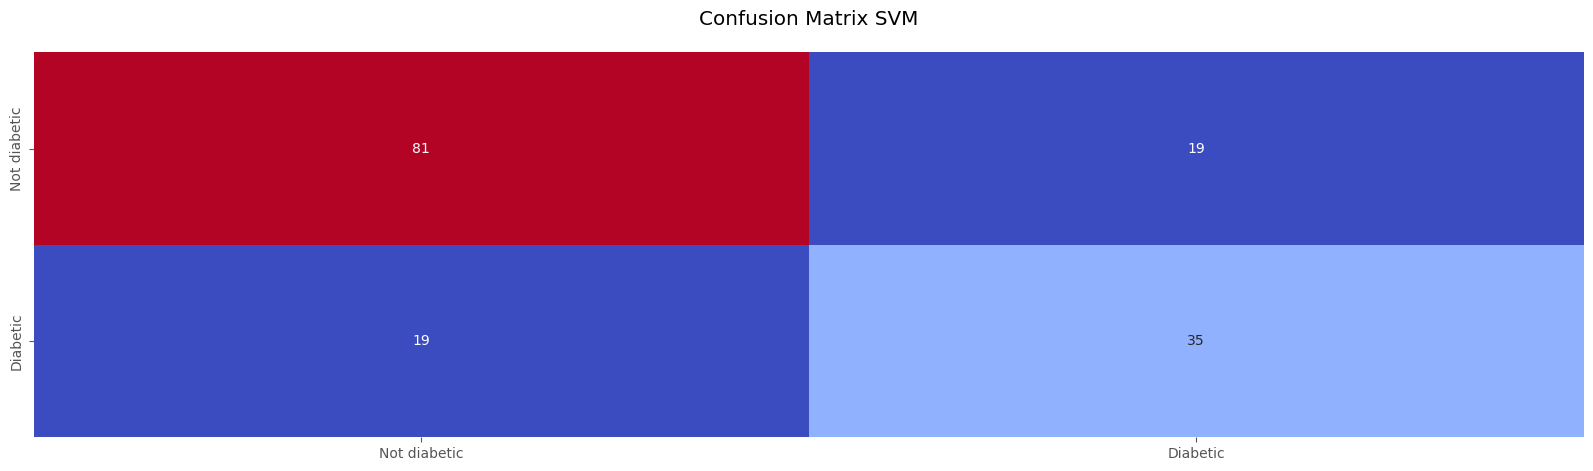

In [131]:
plt.figure(figsize=(20,5)) 
x_testpredect=clasdifer1.predict(x_test)
confusionmatrixx=confusion_matrix(y_test,x_testpredect)
sns.heatmap(confusionmatrixx, annot=True, fmt="d", cmap="coolwarm", cbar=False,yticklabels=["Not diabetic", "Diabetic"], xticklabels=["Not diabetic", "Diabetic"])
plt.title("Confusion Matrix SVM",y=1.05)
plt.show()


<h4 style="color:#d2005bff">
27. Visualizing <span style="color:#007acc">confusion matrix</span> for 
<span style="color:#007acc">Random Forest Classifier</span> on test data using 
<span style="color:#007acc">seaborn.heatmap</span> (labels: Not diabetic vs Diabetic)
</h4>

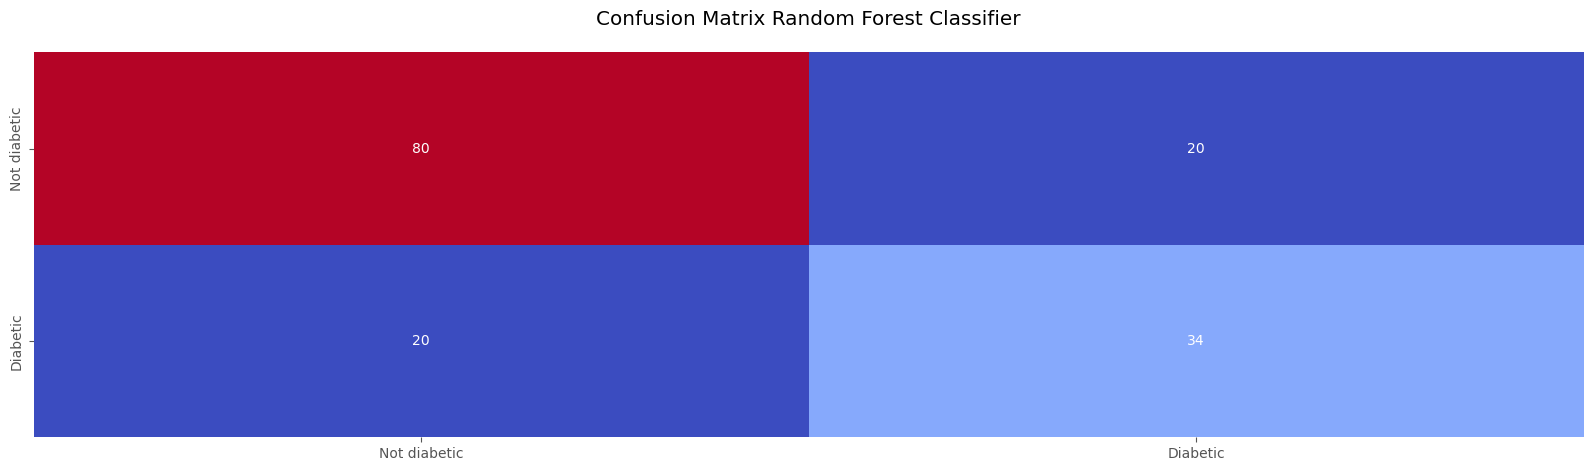

In [132]:
x_testpredect=clasdifer2.predict(x_test)
confusionmatrixx=confusion_matrix(y_test,x_testpredect)
plt.figure(figsize=(20,5))
plt.xlabel="x"
plt.xlabel="y"
sns.heatmap(confusionmatrixx, annot=True, fmt="d", cmap="coolwarm", cbar=False,yticklabels=["Not diabetic", "Diabetic"], xticklabels=["Not diabetic", "Diabetic"])
plt.title("Confusion Matrix Random Forest Classifier",y=1.05)

plt.show()


<h4 style="color:#d2005bff">
28. Plotting <span style="color:#007acc">ROC curves (AUC)</span> and 
<span style="color:#007acc">Precision-Recall curves (AP)</span> 
for <span style="color:#007acc">SVM</span> and <span style="color:#007acc">Random Forest</span> models 
using custom <span style="color:#007acc">plot_curves()</span> function
</h4>

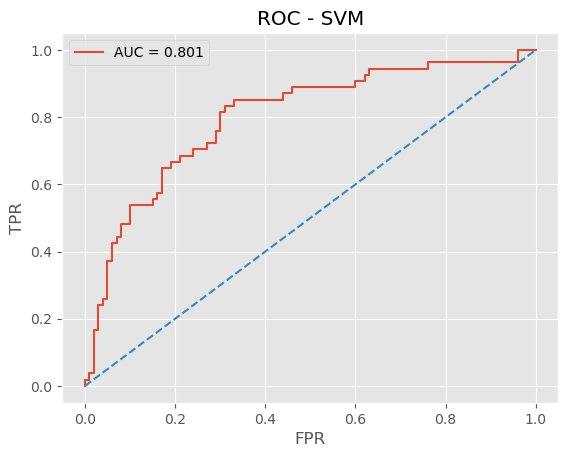

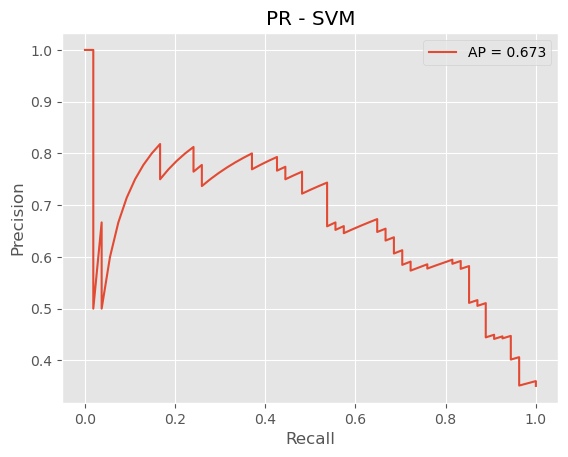

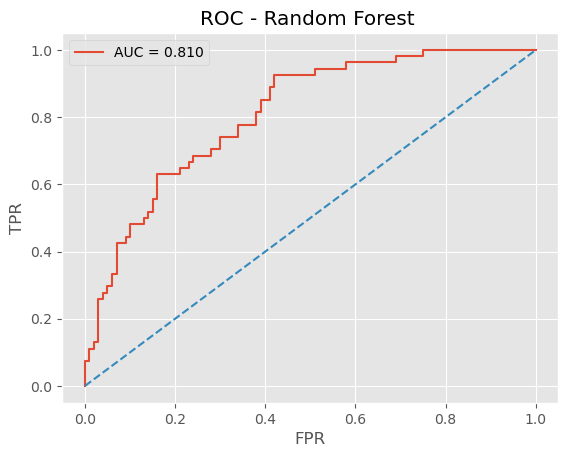

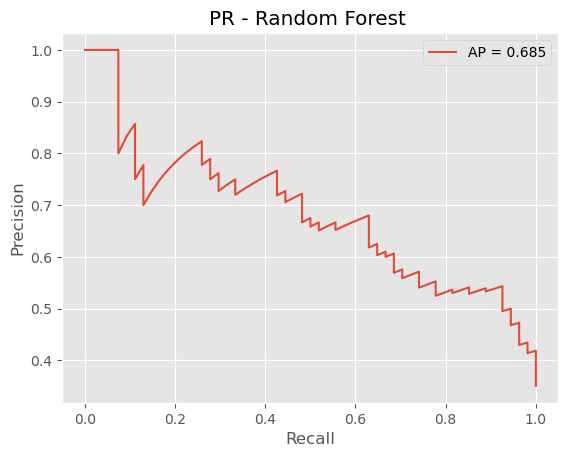

In [133]:
def plot_curves(model, Xte, yte, name):
    p = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(yte, p)
    roc_auc = auc(fpr, tpr)
    fig1, ax1 = plt.subplots()
    ax1.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    ax1.plot([0, 1], [0, 1], '--')
    ax1.set(xlabel="FPR", ylabel="TPR", title=f"ROC - {name}")
    ax1.legend()
    plt.show()
    prec, rec, _ = precision_recall_curve(yte, p)
    ap = average_precision_score(yte, p)
    fig2, ax2 = plt.subplots()
    ax2.plot(rec, prec, label=f"AP = {ap:.3f}")
    ax2.set(xlabel="Recall", ylabel="Precision", title=f"PR - {name}")
    ax2.legend()
    plt.show()

plot_curves(clasdifer1.best_estimator_, x_test, y_test, "SVM")
plot_curves(clasdifer2.best_estimator_, x_test, y_test, "Random Forest ")

<h4 style="color:#d2005bff">
29. Visualizing relationship between <span style="color:#007acc">Insulin levels</span> and 
<span style="color:#007acc">Outcome</span> using <span style="color:#007acc">seaborn.barplot</span> 
(red bars, no confidence interval)
</h4>


C:\Users\Rammah\AppData\Local\Temp\ipykernel_14424\1929715276.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Predicted", y="Insulin", data=diabetes, ci=None, color='darkblue')


<Axes: xlabel='Predicted', ylabel='Insulin'>

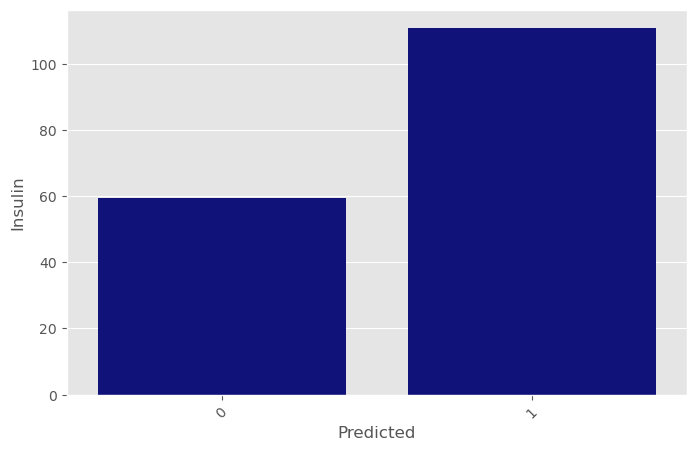

In [140]:
plt.figure(figsize=(8,5))
plt.xticks(rotation=45)
diabetes["Predicted"] = clasdifer1.predict(x.drop(columns="Outcome", errors="ignore"))
sns.barplot(x="Predicted", y="Insulin", data=diabetes, ci=None, color='darkblue')

<h4 style="color:#d2005bff">
30. Visualizing relationship between <span style="color:#007acc">Insulin levels</span> and 
<span style="color:#007acc">Outcome</span> using <span style="color:#007acc">seaborn.barplot</span> 
(red bars, no confidence interval) after Random Forest prediction
</h4>

C:\Users\Rammah\AppData\Local\Temp\ipykernel_14424\1388520892.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Pred_RF", y="Insulin", data=diabetes, ci=None, color='darkred')


Text(0.5, 1.0, 'Insulin vs Predicted Outcome (Random Forest)')

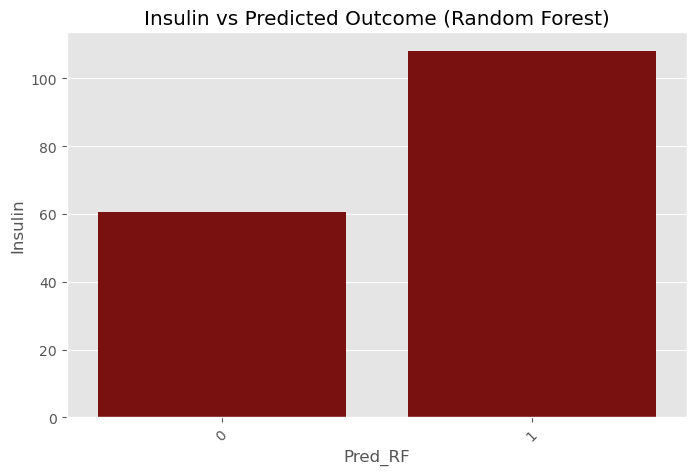

In [139]:
diabetes["Pred_RF"] = clasdifer2.predict(x.drop(columns="Outcome", errors="ignore"))
plt.figure(figsize=(8,5))
plt.xticks(rotation=45)
sns.barplot(x="Pred_RF", y="Insulin", data=diabetes, ci=None, color='darkred')
plt.title("Insulin vs Predicted Outcome (Random Forest)")